# Загружаем библиотеки

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy import stats
from statsmodels.stats.proportion import proportions_ztest

## Загружаем данные

In [5]:
xls = pd.ExcelFile('Новый диплом датасет update.xlsx')               # создаём объект ExcelFile, чтобы посмотреть структуру
xls.sheet_names                                                      # выводим список всех листов 

['Данные', 'Clients', 'Region_dict']

In [6]:
df_orders = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Данные')         # загружаем лист с покупками 
df_clients = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Clients')       # загружаем лист с клиентами 
df_regions = pd.read_excel('Новый диплом датасет update.xlsx', sheet_name='Region_dict')   # загружаем лист со справочником городов и торговых точек 

In [7]:
df_orders.head()

,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-07-17 21:48:15.896
1,100242,191056.0,4151.0,2022-07-07 03:09:39.699
2,100249,200049.0,5688.0,2022-07-29 13:25:59.976
3,100258,206161.0,4330.0,2022-08-15 22:55:02.538
4,100267,190945.0,5488.0,2022-07-05 19:46:47.174


In [8]:
df_clients.head()

,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [9]:
df_regions.head()

,id_trading_point,city
0,1,Петрозаводск
1,2,Дмитров
2,4,Чехов
3,7,Ростов Великий
4,11,Владимир


## Анализ таблиц

In [10]:
df_orders.shape                                                      # выводим количество строк и столбцов в таблице с покупками

(37989, 4)

In [11]:
df_clients.shape                                                     # выводим количество строк и столбцов в таблице с клиентами

(55605, 4)

In [12]:
df_regions.shape                                                     # выводим количество строк и столбцов в таблице со справочником регионов

(66, 2)

Размер таблиц был проверен для контроля корректности загрузки данных и оценки объёма исходной выборки.

In [13]:
df_orders.info()                                                     # выводим информацию о таблице с покупками

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB


In [14]:
df_clients.info()                                                    # выводим информацию о таблице с клиентами

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.7 MB


In [15]:
df_regions.info()                                                    # выводим информацию о таблице со справочником регионов

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_trading_point  66 non-null     int64 
 1   city              66 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


Проведена проверка типов данных, так как для дальнейшего анализа важно, чтобы даты были представлены в формате datetime, суммы платежей - в числовом формате, а идентификаторы клиентов и торговых точек имели согласованный тип в разных таблицах.

In [16]:
orders_nulls = df_orders.isna().sum().reset_index()                       # создаём таблицу с количеством пропусков по таблице покупок
orders_nulls.columns = ['column_name', 'null_count']                      # переименовываем столбцы в таблице с пропусками
orders_nulls['table_name'] = 'df_orders'                                  # добавляем название исходной таблицы

clients_nulls = df_clients.isna().sum().reset_index()                     # создаём таблицу с количеством пропусков по таблице клиентов
clients_nulls.columns = ['column_name', 'null_count']                     # переименовываем столбцы в таблице с пропусками
clients_nulls['table_name'] = 'df_clients'                                # добавляем название исходной таблицы

regions_nulls = df_regions.isna().sum().reset_index()                     # создаём таблицу с количеством пропусков по таблице регионов
regions_nulls.columns = ['column_name', 'null_count']                     # переименовываем столбцы в таблице с пропусками
regions_nulls['table_name'] = 'df_regions'                                # добавляем название исходной таблицы

nulls_report = pd.concat([orders_nulls, clients_nulls, regions_nulls], ignore_index=True)   # объединяем результаты проверки пропусков 

nulls_report                                                              # выводим общий отчёт по пропущенным значениям

,column_name,null_count,table_name
0,id_order,0,df_orders
1,id_client,588,df_orders
2,amt_payment,2144,df_orders
3,dtime_pay,2429,df_orders
4,id_client,0,df_clients
5,dtime_ad,249,df_clients
6,nflag_test,0,df_clients
7,id_trading_point,0,df_clients
8,id_trading_point,0,df_regions
9,city,0,df_regions


In [17]:
orders_rows_before = df_orders.shape[0]                                             # сохраняем исходное количество строк в таблице покупок
clients_rows_before = df_clients.shape[0]                                           # сохраняем исходное количество строк в таблице клиентов
regions_rows_before = df_regions.shape[0]                                           # сохраняем исходное количество строк в таблице регионов
df_orders = df_orders.dropna()                                                      # удаляем строки с пропущенными значениями из таблицы покупок
df_clients = df_clients.dropna()                                                    # удаляем строки с пропущенными значениями из таблицы клиентов
df_regions = df_regions.dropna()                                                    # удаляем строки с пропущенными значениями из таблицы регионов
orders_rows_after = df_orders.shape[0]                                              # сохраняем новое количество строк в таблице покупок
clients_rows_after = df_clients.shape[0]                                            # сохраняем новое количество строк в таблице клиентов
regions_rows_after = df_regions.shape[0]                                            # сохраняем новое количество строк в таблице регионов

print('Удалено строк из df_orders:', orders_rows_before - orders_rows_after)        # выводим, сколько строк было удалено из таблицы покупок
print('Удалено строк из df_clients:', clients_rows_before - clients_rows_after)     # выводим, сколько строк было удалено из таблицы клиентов
print('Удалено строк из df_regions:', regions_rows_before - regions_rows_after)     # выводим, сколько строк было удалено из таблицы регионов

Удалено строк из df_orders: 2429
Удалено строк из df_clients: 249
Удалено строк из df_regions: 0


1. На этапе предобработки данных была проведена проверка трёх исходных таблиц на наличие пропущенных значений. 
2. Так как пропуски в ключевых полях могут искажать результаты A/B-теста, строки с отсутствующими значениями были удалены. 
3. Замена пропусков на нули в данном случае не использовалась, поскольку нулевые значения могли бы искусственно занизить сумму платежей, количество покупок или привести к некорректному определению города и торговой точки клиента.
4. В рамках очистки были удалены именно пропущенные значения, то есть значения NaN. 
Числовые нули не удалялись, так как в некоторых столбцах они могут иметь содержательный смысл. 

In [18]:
trading_points_by_city = df_regions.groupby('city')['id_trading_point'].\
                       nunique().reset_index()            # группируем данные по городам и считаем количество уникальных торговых точек в каждом городе
trading_points_by_city = trading_points_by_city.\
                       rename(columns={'id_trading_point': 'trading_points_count'})   # переименовываем столбец с количеством торговых точек
trading_points_by_city = trading_points_by_city.\
                       sort_values(by='trading_points_count', ascending=False)        # сортируем города по количеству торговых точек по убыванию

trading_points_by_city                                                                # выводим получившуюся таблицу

,city,trading_points_count
15,Санкт-Петербург,11
7,Москва,11
4,Казань,6
10,Новосибирск,6
6,Красноярск,5
5,Краснодар,4
14,Самара,4
8,Мурманск,2
18,Сочи,2
16,Саратов,2


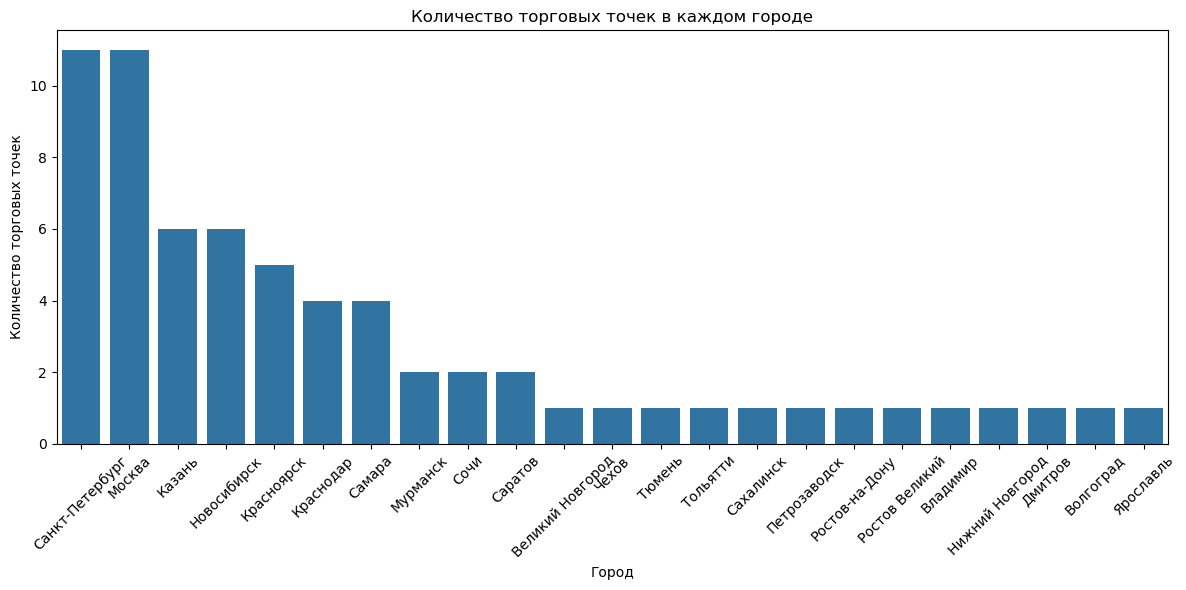

In [19]:
plt.figure(figsize=(12, 6))                                                         # задаем размер графика
sns.barplot(data=trading_points_by_city, x='city', y='trading_points_count')        # строим столбчатую диаграмму количества торговых точек по городам
plt.title('Количество торговых точек в каждом городе')                              # оформление графика
plt.xlabel('Город')
plt.ylabel('Количество торговых точек')
plt.xticks(rotation=45)                                                             # поворачиваем подписи городов на оси X для удобства чтения
plt.tight_layout()                                                                  # добавляем автоматическую настройку отступов

plt.show()                                                                          # отображаем график

По результатам группировки видно, что торговые точки распределены по городам неравномерно. 
Наибольшее количество торговых точек находится в Санкт-Петербурге и Москве - по 11 точек в каждом городе. 
Также относительно большое количество торговых точек представлено в Казани и Новосибирске - по 6 точек. 
В большинстве остальных городов находится только одна торговая точка.

Такое распределение важно учитывать при дальнейшем анализе A/B-теста, так как в городах с малым количеством торговых точек результаты могут быть менее устойчивыми из-за меньшего объёма данных.

## Объединение таблиц

In [20]:
df_payments_by_client = df_orders.groupby('id_client').agg(                       # группируем таблицу покупок по клиентам
    amt_payment=('amt_payment', 'sum'),                                           # считаем общую сумму платежей по каждому клиенту
).reset_index()                                                                   # сбрасываем индекс, чтобы id_client снова стал обычным столбцом

df_payments_by_client.head()                                                      # выводим первые строки агрегированной таблицы

,id_client,amt_payment
0,178561.0,3052.0
1,178562.0,2439.0
2,178563.0,768.0
3,178565.0,958.0
4,178566.0,5474.0


In [21]:
df_payments_by_client.shape                                                       # проверяем размер таблицы

(28383, 2)

In [22]:
df_payments_by_client['id_client'].duplicated().sum()                             # проверяем дубликаты клиентов

np.int64(0)

In [23]:
clients_count_before_merge = df_clients.shape[0]                                  # сохраняем количество клиентов до объединения
df_ab = df_clients.merge(df_payments_by_client, on='id_client', how='left')       # объединяем клиентскую таблицу с агрегированной таблицей платежей
clients_count_after_merge = df_ab.shape[0]                                        # сохраняем количество строк после объединения

print('Количество клиентов до объединения:', clients_count_before_merge)          # выводим количество клиентов до и после объединения
print('Количество строк после объединения:', clients_count_after_merge)

Количество клиентов до объединения: 55356
Количество строк после объединения: 55356


In [24]:
clients_count_before_merge == clients_count_after_merge                           # проверяем, что после объединения сохранились все клиенты 

True

In [25]:
df_ab['amt_payment'] = df_ab['amt_payment'].fillna(0)                # заполняем нулями сумму платежей у клиентов, которые не совершали покупок 

In [26]:
df_ab['amt_payment'].isna().sum()                                    # проверяем, остались ли пропуски в сумме платежей после заполнения нулями

np.int64(0)

In [27]:
rows_before_city_merge = df_ab.shape[0]                                            # сохраняем количество строк до добавления города
df_ab = df_ab.merge(df_regions, on='id_trading_point', how='left')                 # добавляем город к каждой торговой точке через справочник регионов
rows_after_city_merge = df_ab.shape[0]                                             # сохраняем количество строк после добавления города

print('Количество строк до добавления города:', rows_before_city_merge)            # выводим количество строк до и после добавления города
print('Количество строк после добавления города:', rows_after_city_merge)

Количество строк до добавления города: 55356
Количество строк после добавления города: 55356


In [28]:
df_ab['city'].isna().sum()                                                          # проверяем, всем ли клиентам подтянулся город

np.int64(0)

In [29]:
df_ab['payment_flag'] = np.where(df_ab['amt_payment'] > 0, 1, 0)   # создаём флаг платежа: 1 — клиент совершил покупку, 0 — клиент не совершил покупку

In [30]:
df_ab['payment_flag'].value_counts()                               # проверяем количество клиентов с покупкой и без покупки                

payment_flag
1    28383
0    26973
Name: count, dtype: int64

Таблица с платежами была агрегирована до уровня клиента, поскольку один клиент мог совершить несколько покупок. 
Для каждого клиента была рассчитана общая сумма платежей.

Далее агрегированная таблица платежей была объединена с клиентской таблицей по полю id_client. 
Для объединения использовался тип left join, что позволило сохранить всех клиентов из клиентской таблицы, включая клиентов без покупок.

У клиентов, которые не совершали покупки, пропущенные значения в сумме платежей были заполнены нулями. 
Такое заполнение является корректным, так как отсутствие записи о покупке означает отсутствие платежа.

После этого с помощью справочника регионов к каждой торговой точке был добавлен город. 
Также был создан флаг payment_flag, который принимает значение 1, если клиент совершил хотя бы одну покупку, и 0 — если покупок не было.

## Автоматизация статистических вычислений

In [33]:
def test_calc(r1, r2, alpha=0.05):                                             # создаём функцию для расчёта t-критерия Стьюдента и p-value
    r1 = pd.Series(r1).dropna()                                                # удаляем пропущенные значения из первой выборки
    r2 = pd.Series(r2).dropna()                                                # удаляем пропущенные значения из второй выборки
    s, p = stats.ttest_ind(r1, r2, equal_var=False)                            # рассчитываем t-критерий Стьюдента и p-value
    
    print(f't-критерий: {s}')                                                  # выводим значение t-критерия
    print(f'p-value: {p}')                                                     # выводим значение p-value
    
    if p < alpha:                                                              # сравниваем p-value с уровнем значимости alpha
        print('Существует статистически значимая разница между средними.')
    else:
        print('Статистически значимой разницы между средними нет.')
    
    return s, p                                                                 # возвращаем значение критерия и p-value

In [34]:
def mann_whitney_func(r1, r2, alpha=0.05):                                      # создаём функцию для расчёта критерия Манна — Уитни и p-value
    r1 = pd.Series(r1).dropna()                                                 # удаляем пропущенные значения из первой выборки
    r2 = pd.Series(r2).dropna()                                                 # удаляем пропущенные значения из второй выборки
    s, p = stats.mannwhitneyu(r1, r2, alternative='two-sided')                  # рассчитываем критерий Манна — Уитни и p-value
    
    print(f'U-статистика Манна-Уитни: {s}')                                     # выводим значение критерия Манна — Уитни
    print(f'p-value: {p}')                                                      # выводим значение p-value
        
    if p < alpha:                                                               # сравниваем p-value с уровнем значимости alpha
        print('Существует статистически значимая разница между распределениями выборок.')
    else:
        print('Нет статистически значимой разницы между распределениями выборок.')
    
    return s, p                                                                 # возвращаем значение критерия и p-value

In [35]:
r1 = df_ab[df_ab['nflag_test'] == 0]['amt_payment']                             # формируем выборку платежей контрольной группы
r2 = df_ab[df_ab['nflag_test'] == 1]['amt_payment']                             # формируем выборку платежей тестовой группы

test_calc(r1, r2)                                                               # запускаем t-тест
mann_whitney_func(r1, r2)                                                       # запускаем критерий Манна — Уитни

t-критерий: -6.3807276281756105
p-value: 1.7768574179643183e-10
Существует статистически значимая разница между средними.
U-статистика Манна-Уитни: 370074960.5
p-value: 5.082016727027916e-10
Существует статистически значимая разница между распределениями выборок.


(np.float64(370074960.5), np.float64(5.082016727027916e-10))

На данном этапе были созданы функции для автоматизации статистических вычислений. 
Функция test_calc рассчитывает t-критерий Стьюдента и p-value для сравнения средних двух независимых выборок. 
Функция mann_whitney_func рассчитывает критерий Манна — Уитни и p-value для сравнения распределений двух независимых выборок.

Обе функции принимают две выборки r1 и r2, а также уровень значимости alpha, который по умолчанию равен 0.05. 
По результатам расчёта функции выводят значение статистического критерия, p-value и текстовый вывод о наличии или отсутствии статистически значимых различий.

## Чистка неверно заполненных точек

In [37]:
zero_payment_points = []                                   # создаём пустой список для торговых точек, где в тестовой или контрольной группе нет оплат

for point in df_ab['id_trading_point'].unique():                                 # запускаем цикл по всем уникальным торговым точкам
    df_point = df_ab[df_ab['id_trading_point'] == point]                         # отбираем данные только по текущей торговой точке
    control_sum = df_point[df_point['nflag_test'] == 0]['amt_payment'].sum()     # считаем сумму платежей в контрольной группе текущей торговой точки
    test_sum = df_point[df_point['nflag_test'] == 1]['amt_payment'].sum()        # считаем сумму платежей в тестовой группе текущей торговой точки
    if control_sum == 0 or test_sum == 0:                                        # проверяем, есть ли хотя бы в одной из групп нулевая сумма платежей
        zero_payment_points.append(point)                                        # если условие выполнено, добавляем торговую точку в список проблемных

print(zero_payment_points)                                                       # выводим список торговых точек, где в одной из групп нет оплат

[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(46), np.int64(228), np.int64(26), np.int64(603), np.int64(810), np.int64(800), np.int64(7), np.int64(23), np.int64(4), np.int64(1), np.int64(13)]


In [38]:
empty_group_points = []                                    # cоздаём пустой список для торговых точек, где отсутствует контрольная или тестовая группа

for point in df_ab['id_trading_point'].unique():                                 # запускаем цикл по всем уникальным торговым точкам
    df_point = df_ab[df_ab['id_trading_point'] == point]                         # отбираем данные только по текущей торговой точке
    control_count = df_point[df_point['nflag_test'] == 0]['id_client'].count()   # считаем количество клиентов в контрольной группе текущей торговой точки
    test_count = df_point[df_point['nflag_test'] == 1]['id_client'].count()      # считаем количество клиентов в тестовой группе текущей торговой точки
    if control_count == 0 or test_count == 0:                                    # проверяем, отсутствует ли одна из групп
        empty_group_points.append(point)                                         # если условие выполнено, добавляем торговую точку в список проблемных

print(empty_group_points)                                   # выводим список торговых точек, где отсутствует контрольная или тестовая группа

[np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228), np.int64(603), np.int64(810), np.int64(800)]


На данном этапе были созданы два списка некорректно заполненных торговых точек.

В первый список были добавлены торговые точки, в которых в контрольной или тестовой группе сумма платежей равна нулю. Такие точки не подходят для дальнейшего сравнения платежей, так как в одной из групп отсутствуют оплаты.

Во второй список были добавлены торговые точки, в которых отсутствует контрольная или тестовая группа. Такие точки также не подходят для анализа A/B-теста, поскольку для корректного сравнения необходимо наличие обеих групп.

## Расчет общих результатов A/B-теста

In [39]:
excluded_points = set(zero_payment_points) | set(empty_group_points)            # объединяем список точек без оплат и список точек с пустой группой
df_filtered = df_ab[~df_ab['id_trading_point'].isin(excluded_points)].reset_index(drop=True)     # удаляем некорректные торговые точки 

df_filtered                                                                                            # выводим очищенную таблицу

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,payment_flag
0,180844,2022-06-08 18:38:41.414,0,212,5349.0,Красноярск,1
1,226069,2022-07-11 16:28:38.511,1,54,0.0,Мурманск,0
2,183981,2022-06-16 12:23:59.289,1,991,6322.0,Казань,1
3,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
4,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
...,...,...,...,...,...,...,...
45313,188702,2022-06-28 06:16:25.664,0,453,1323.0,Санкт-Петербург,1
45314,244069,2022-08-08 00:12:31.319,1,991,0.0,Казань,0
45315,189084,2022-06-29 04:34:42.610,1,439,7146.0,Казань,1
45316,182758,2022-06-13 11:28:37.856,1,573,13720.0,Санкт-Петербург,1


In [40]:
df_filtered['id_trading_point'].isin(excluded_points).sum()       # проверяем, остались ли в очищенной таблице некорректные торговые точки

np.int64(0)

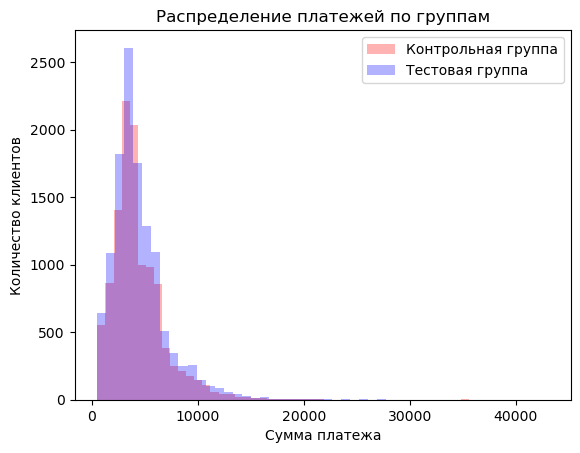

In [41]:
df_filtered_for_hist = df_filtered[df_filtered['amt_payment'] > 0]          # создаём отдельную таблицу только для графика, исключая нулевые платежи

plt.hist(                                                                    # строим гистограмму платежей для контрольной группы
    df_filtered_for_hist[df_filtered_for_hist['nflag_test'] == 0]['amt_payment'],
    color='red',
    alpha=0.3,
    label='Контрольная группа',
    bins=50
)

plt.hist(                                                                    # строим гистограмму платежей для тестовой группы
    df_filtered_for_hist[df_filtered_for_hist['nflag_test'] == 1]['amt_payment'],
    color='blue',
    alpha=0.3,
    label='Тестовая группа',
    bins=50
)

plt.xlabel('Сумма платежа')                                                 # оформление графика
plt.ylabel('Количество клиентов')
plt.title('Распределение платежей по группам')
plt.legend(loc='upper right')

plt.show()                                                                  # отображаем график

In [42]:
r1_payment = df_filtered[df_filtered['nflag_test'] == 0]['amt_payment']                # формируем выборку платежей контрольной группы
r2_payment = df_filtered[df_filtered['nflag_test'] == 1]['amt_payment']                # формируем выборку платежей тестовой группы

In [43]:
test_calc(r1_payment, r2_payment)                                                      # сравниваем средние платежи в контрольной и тестовой группах

t-критерий: -9.452654239576423
p-value: 3.456057606199937e-21
Существует статистически значимая разница между средними.


(np.float64(-9.452654239576423), np.float64(3.456057606199937e-21))

In [44]:
control_avg_payment = r1_payment.mean()                                                 # считаем средний платеж в контрольной группе
test_avg_payment = r2_payment.mean()                                                    # считаем средний платеж в тестовой группе

print('Средний платеж в контрольной группе:', control_avg_payment)                      # выводим средний платеж в контрольной группе
print('Средний платеж в тестовой группе:', test_avg_payment)                            # выводим средний платеж в тестовой группе
print('Разница средних платежей:', test_avg_payment - control_avg_payment)              # считаем разницу между средними платежами

Средний платеж в контрольной группе: 2189.1884317754557
Средний платеж в тестовой группе: 2452.2773446201827
Разница средних платежей: 263.088912844727


Для сравнения средних платежей в контрольной и тестовой группах был применён t-тест Стьюдента с помощью функции test_calc.

Средний платеж в контрольной группе составил 2189.19, а в тестовой группе — 2452.28. Разница средних платежей составила 263.09 в пользу тестовой группы.

Полученное значение p-value = 3.456e-21, что значительно меньше уровня значимости 0.05. Следовательно, на уровне значимости 5% можно сделать вывод, что между контрольной и тестовой группами существует статистически значимая разница по среднему платежу.

Таким образом, пуш-уведомления показали лучший результат по среднему платежу по сравнению с баннерами.

In [45]:
r1_conversion = df_filtered[df_filtered['nflag_test'] == 0]['payment_flag']             # формируем выборку флагов платежа для контрольной группы
r2_conversion = df_filtered[df_filtered['nflag_test'] == 1]['payment_flag']             # формируем выборку флагов платежа для тестовой группы

In [46]:
test_calc(r1_conversion, r2_conversion)

t-критерий: -9.282362400356972
p-value: 1.7284765137365496e-20
Существует статистически значимая разница между средними.


(np.float64(-9.282362400356972), np.float64(1.7284765137365496e-20))

In [47]:
control_conversion = r1_conversion.mean()                                                # считаем конверсию в платеж в контрольной группе
test_conversion = r2_conversion.mean()                                                   # считаем конверсию в платеж в тестовой группе

print('Конверсия в платеж в контрольной группе:', control_conversion)                    # выводим конверсию в контрольной группе
print('Конверсия в платеж в тестовой группе:', test_conversion)                          # выводим конверсию в платеж в тестовой группе
print('Разница конверсий:', test_conversion - control_conversion)                        # считаем разницу конверсий

Конверсия в платеж в контрольной группе: 0.49975954181786386
Конверсия в платеж в тестовой группе: 0.5432835820895522
Разница конверсий: 0.043524040271688325


Для сравнения конверсии в платеж также была применена функция test_calc. В качестве выборок использовались значения флага платежа: 1 - клиент совершил платеж, 0 - клиент не совершил платеж. Среднее значение такого флага соответствует конверсии в платеж.

Конверсия в платеж в контрольной группе составила 49.98%, а в тестовой группе - 54.33%. Разница конверсий составила 4.35 процентного пункта в пользу тестовой группы.

Полученное значение p-value = 1.728e-20, что меньше уровня значимости 0.05. Следовательно, на уровне значимости 5% можно сделать вывод, что между контрольной и тестовой группами существует статистически значимая разница по конверсии в платеж.

Таким образом, пуш-уведомления также показали лучший результат по конверсии в покупку по сравнению с баннерами.

In [48]:
mann_whitney_func(r1_payment, r2_payment)                                        # сравниваем распределения платежей в контрольной и тестовой группах

U-статистика Манна-Уитни: 243344369.0
p-value: 3.008345273971901e-24
Существует статистически значимая разница между распределениями выборок.


(np.float64(243344369.0), np.float64(3.008345273971901e-24))

Для дополнительного сравнения платежей в контрольной и тестовой группах был применён критерий Манна — Уитни с помощью функции mann_whitney_func.

По результатам теста получено значение p-value = 3.008e-24, что значительно меньше уровня значимости 0.05. Следовательно, на уровне значимости 5% между распределениями платежей контрольной и тестовой групп существует статистически значимая разница.

Таким образом, критерий Манна — Уитни подтверждает результаты t-теста: платежи в тестовой и контрольной группах различаются статистически значимо. С учётом того, что ранее средний платёж в тестовой группе оказался выше, можно сделать вывод, что тестовая механика с пуш-уведомлениями показывает лучший результат по платежам, чем контрольная механика с баннерами.

## Сегментация результатов A/B-теста

In [49]:
df_moscow = df_filtered[df_filtered['city'] == 'Москва'].copy()                   # отбираем данные только по городу Москва

df_moscow.head()                                                                   # выводим первые строки таблицы по Москве

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,payment_flag
4,195818,2022-07-16 01:30:59.088,1,2652,4021.0,Москва,1
5,274394,2022-06-25 00:46:07.492,1,2652,0.0,Москва,0
8,201373,2022-07-29 22:27:46.612,1,6543,5009.0,Москва,1
11,205352,2022-08-08 20:59:32.806,0,2652,0.0,Москва,0
21,185585,2022-06-20 12:40:52.026,0,2652,0.0,Москва,0


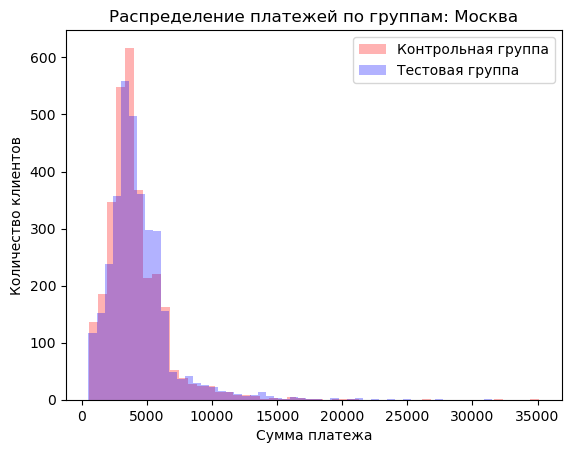

In [50]:
df_moscow_for_hist = df_moscow[df_moscow['amt_payment'] > 0]                 # создаём отдельную таблицу только для графика, исключая нулевые платежи

plt.hist(                                                                    # строим гистограмму платежей для контрольной группы в Москве
    df_moscow_for_hist[df_moscow_for_hist['nflag_test'] == 0]['amt_payment'],
    color='red',
    alpha=0.3,
    label='Контрольная группа',
    bins=50
)

plt.hist(                                                                    # строим гистограмму платежей для тестовой группы
    df_moscow_for_hist[df_moscow_for_hist['nflag_test'] == 1]['amt_payment'],
    color='blue',
    alpha=0.3,
    label='Тестовая группа',
    bins=50
)

plt.xlabel('Сумма платежа')                                                 # оформление графика
plt.ylabel('Количество клиентов')
plt.title('Распределение платежей по группам: Москва')
plt.legend(loc='upper right')

plt.show()                                                                  # отображаем график

In [51]:
r1_payment_moscow = df_moscow[df_moscow['nflag_test'] == 0]['amt_payment']       # формируем выборку платежей контрольной группы по Москве
r2_payment_moscow = df_moscow[df_moscow['nflag_test'] == 1]['amt_payment']       # формируем выборку платежей тестовой группы по Москве

In [52]:
test_calc(r1_payment_moscow, r2_payment_moscow)

t-критерий: -7.672097996911047
p-value: 1.8199520669736726e-14
Существует статистически значимая разница между средними.


(np.float64(-7.672097996911047), np.float64(1.8199520669736726e-14))

In [53]:
control_avg_payment_moscow = r1_payment_moscow.mean()                                # считаем средний платеж в контрольной группе по Москве
test_avg_payment_moscow = r2_payment_moscow.mean()                                   # считаем средний платеж в тестовой группе по Москве

print('Средний платеж в контрольной группе, Москва:', control_avg_payment_moscow)    # выводим средний платеж в контрольной группе
print('Средний платеж в тестовой группе, Москва:', test_avg_payment_moscow)          # выводим средний платеж в тестовой группе
print('Разница средних платежей, Москва:', test_avg_payment_moscow - control_avg_payment_moscow)   # выводим разницу средних платежей

Средний платеж в контрольной группе, Москва: 1986.18059125964
Средний платеж в тестовой группе, Москва: 2367.9590805347243
Разница средних платежей, Москва: 381.7784892750842


In [54]:
r1_conversion_moscow = df_moscow[df_moscow['nflag_test'] == 0]['payment_flag']      # формируем выборку флагов платежа для контрольной группы по Москве
r2_conversion_moscow = df_moscow[df_moscow['nflag_test'] == 1]['payment_flag']      # формируем выборку флагов платежа для тестовой группы по Москве

In [55]:
test_calc(r1_conversion_moscow, r2_conversion_moscow)               # сравниваем конверсию в платеж между контрольной и тестовой группами по Москве

t-критерий: -6.19047063650437
p-value: 6.18851179009111e-10
Существует статистически значимая разница между средними.


(np.float64(-6.19047063650437), np.float64(6.18851179009111e-10))

In [56]:
control_conversion_moscow = r1_conversion_moscow.mean()                                   # считаем конверсию в платеж в контрольной группе по Москве
test_conversion_moscow = r2_conversion_moscow.mean()                                      # считаем конверсию в платеж в тестовой группе по Москве

print('Конверсия в платеж в контрольной группе, Москва:', control_conversion_moscow)      # выводим конверсию в платеж в контрольной группе
print('Конверсия в платеж в тестовой группе, Москва:', test_conversion_moscow)            # выводим конверсию в платеж в тестовой группе
print('Разница конверсий, Москва:', test_conversion_moscow - control_conversion_moscow)   # выводим разницу конверсий

Конверсия в платеж в контрольной группе, Москва: 0.4879498714652956
Конверсия в платеж в тестовой группе, Москва: 0.5435278774046299
Разница конверсий, Москва: 0.05557800593933432


In [57]:
mann_whitney_func(r1_payment_moscow, r2_payment_moscow)                        # сравниваем распределения платежей в контрольной и тестовой группах

U-статистика Манна-Уитни: 17582441.5
p-value: 7.010591402203484e-16
Существует статистически значимая разница между распределениями выборок.


(np.float64(17582441.5), np.float64(7.010591402203484e-16))

Для города Москва был проведён отдельный анализ результатов A/B-теста. В анализ вошли только клиенты из очищенной таблицы, относящиеся к московским торговым точкам.
По результатам сравнения средних платежей с помощью t-теста было получено p-value = 1.8195e-14, что меньше уровня значимости 0.05. Следовательно, между контрольной и тестовой группами в Москве существует статистически значимая разница по среднему платежу.
Средний платеж в контрольной группе составил 1986.19, а в тестовой группе — 2367.96. Разница средних платежей составила 381.77 в пользу тестовой группы. Это означает, что в Москве тестовая механика показывает более высокий средний платеж.
Также была проверена конверсия в платеж. Конверсия в контрольной группе составила 48.80%, а в тестовой группе — 54.36%. Разница конверсий составила 5.56 процентного пункта в пользу тестовой группы. По результатам t-теста p-value = 6.1885e-10, что меньше 0.05, поэтому различие в конверсии также является статистически значимым.
Дополнительно был применён критерий Манна — Уитни для сравнения распределений платежей. Полученное p-value = 7.0185e-15 меньше 0.05, следовательно, распределения платежей в контрольной и тестовой группах статистически значимо различаются.
Таким образом, по Москве тестовая механика с пуш-уведомлениями показала лучший результат по сравнению с контрольной механикой с баннерами: средний платеж выше, конверсия в платеж выше, и различия статистически значимы.

In [58]:
df_spb = df_filtered[df_filtered['city'] == 'Санкт-Петербург'].copy()                   # отбираем данные только по городу Санкт-Петербург

df_spb.head()                                                                           # выводим первые строки таблицы по Санкт-Петербургу

,id_client,dtime_ad,nflag_test,id_trading_point,amt_payment,city,payment_flag
3,254313,2022-06-19 22:18:01.770,1,453,0.0,Санкт-Петербург,0
6,200225,2022-07-27 00:18:47.370,0,453,4372.0,Санкт-Петербург,1
10,205357,2022-08-08 21:22:23.684,0,453,2818.0,Санкт-Петербург,1
19,248371,2022-08-02 01:44:51.638,0,112,0.0,Санкт-Петербург,0
22,277149,2022-07-15 01:31:37.312,0,394,0.0,Санкт-Петербург,0


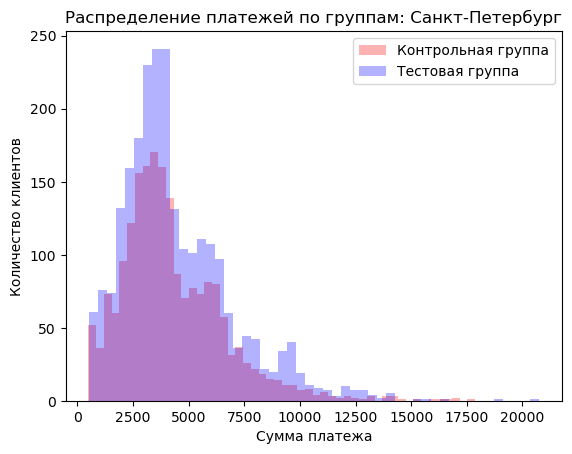

In [60]:
df_spb_for_hist = df_spb[df_spb['amt_payment'] > 0]                          # создаём отдельную таблицу только для графика, исключая нулевые платежи

plt.hist(                                                                    # строим гистограмму платежей для контрольной группы в Санкт-Петербурге
    df_spb_for_hist[df_spb_for_hist['nflag_test'] == 0]['amt_payment'],
    color='red',
    alpha=0.3,
    label='Контрольная группа',
    bins=50
)

plt.hist(                                                                    # строим гистограмму платежей для тестовой группы
    df_spb_for_hist[df_spb_for_hist['nflag_test'] == 1]['amt_payment'],
    color='blue',
    alpha=0.3,
    label='Тестовая группа',
    bins=50
)

plt.xlabel('Сумма платежа')                                                 # оформление графика
plt.ylabel('Количество клиентов')
plt.title('Распределение платежей по группам: Санкт-Петербург')
plt.legend(loc='upper right')

plt.show()                                                                  # отображаем график

In [61]:
r1_payment_spb = df_spb[df_spb['nflag_test'] == 0]['amt_payment']       # формируем выборку платежей контрольной группы по Санкт-Петербургу
r2_payment_spb = df_spb[df_spb['nflag_test'] == 1]['amt_payment']       # формируем выборку платежей тестовой группы по Санкт-Петербургу

In [62]:
test_calc(r1_payment_spb, r2_payment_spb)

t-критерий: -8.760567570492698
p-value: 2.303567502922061e-18
Существует статистически значимая разница между средними.


(np.float64(-8.760567570492698), np.float64(2.303567502922061e-18))

In [63]:
control_avg_payment_spb = r1_payment_spb.mean()                                # считаем средний платеж в контрольной группе по Санкт-Петербургу
test_avg_payment_spb = r2_payment_spb.mean()                                   # считаем средний платеж в тестовой группе по Санкт-Петербургу

print('Средний платеж в контрольной группе, Санкт-Петербург:', control_avg_payment_spb)    # выводим средний платеж в контрольной группе
print('Средний платеж в тестовой группе, Санкт-Петербург:', test_avg_payment_spb)          # выводим средний платеж в тестовой группе
print('Разница средних платежей, Санкт-Петербург:', test_avg_payment_spb - control_avg_payment_spb)   # выводим разницу средних платежей

Средний платеж в контрольной группе, Санкт-Петербург: 1913.5586377988272
Средний платеж в тестовой группе, Санкт-Петербург: 2427.462542182227
Разница средних платежей, Санкт-Петербург: 513.9039043833998


In [64]:
r1_conversion_spb = df_spb[df_spb['nflag_test'] == 0]['payment_flag']    # формируем выборку флагов платежа для контрольной группы по Санкт-Петербургу
r2_conversion_spb = df_spb[df_spb['nflag_test'] == 1]['payment_flag']      # формируем выборку флагов платежа для тестовой группы по Санкт-Петербургу

In [65]:
test_calc(r1_conversion_spb, r2_conversion_spb)               # сравниваем конверсию в платеж между контрольной и тестовой группами по Санкт-Петербургу

t-критерий: -9.352479120817705
p-value: 1.0657220952695895e-20
Существует статистически значимая разница между средними.


(np.float64(-9.352479120817705), np.float64(1.0657220952695895e-20))

In [66]:
control_conversion_spb = r1_conversion_spb.mean()                        # считаем конверсию в платеж в контрольной группе по Санкт-Петербургу
test_conversion_spb = r2_conversion_spb.mean()                           # считаем конверсию в платеж в тестовой группе по Санкт-Петербургу

print('Конверсия в платеж в контрольной группе, Санкт-Петербург:', control_conversion_spb)      # выводим конверсию в платеж в контрольной группе
print('Конверсия в платеж в тестовой группе, Санкт-Петербург:', test_conversion_spb)            # выводим конверсию в платеж в тестовой группе
print('Разница конверсий, Санкт-Петербург:', test_conversion_spb - control_conversion_spb)   # выводим разницу коныерсий

Конверсия в платеж в контрольной группе, Санкт-Петербург: 0.44835363103292736
Конверсия в платеж в тестовой группе, Санкт-Петербург: 0.5471316085489314
Разница конверсий, Санкт-Петербург: 0.09877797751600403


In [67]:
mann_whitney_func(r1_payment_spb, r2_payment_spb)                        # сравниваем распределения платежей в контрольной и тестовой группах

U-статистика Манна-Уитни: 8809444.5
p-value: 2.0392184217953754e-20
Существует статистически значимая разница между распределениями выборок.


(np.float64(8809444.5), np.float64(2.0392184217953754e-20))

Для города Санкт-Петербург был проведён отдельный анализ результатов A/B-теста. В анализ вошли только клиенты из очищенной таблицы, относящиеся к торговым точкам Санкт-Петербурга. По результатам сравнения средних платежей с помощью t-теста было получено p-value ≈ 2.38e-18, что меньше уровня значимости 0.05. Следовательно, между контрольной и тестовой группами в Санкт-Петербурге существует статистически значимая разница по среднему платежу.
Средний платеж в контрольной группе составил 1913.56, а в тестовой группе — 2427.47. Разница средних платежей составила 513.90 в пользу тестовой группы. Это означает, что в Санкт-Петербурге тестовая механика показывает более высокий средний платеж.
Также была проверена конверсия в платеж. Конверсия в контрольной группе составила 44.83%, а в тестовой группе — 54.71%. Разница конверсий составила 9.88 процентного пункта в пользу тестовой группы. По результатам t-теста для конверсии p-value ≈ 1.87e-20, что меньше 0.05, поэтому различие в конверсии также является статистически значимым.
Дополнительно был применён критерий Манна — Уитни для сравнения распределений платежей. Полученное p-value ≈ 2.03e-20 меньше 0.05, следовательно, распределения платежей в контрольной и тестовой группах статистически значимо различаются.
Таким образом, по Санкт-Петербургу тестовая механика с пуш-уведомлениями показала лучший результат по сравнению с контрольной механикой с баннерами: средний платеж выше, конверсия в платеж выше, и различия статистически значимы.

Город: Красноярск


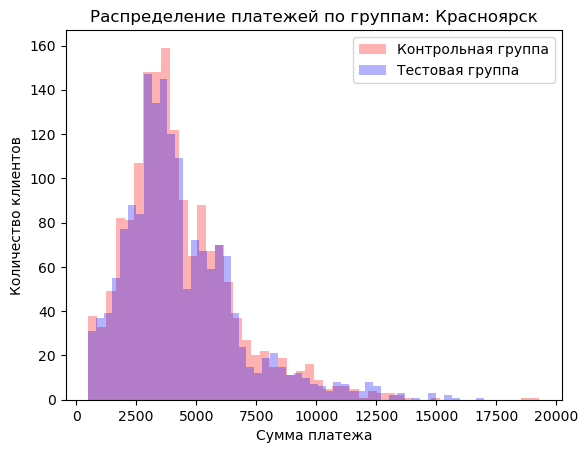

Средний платеж в контрольной группе: 2428.7775862068966
Средний платеж в тестовой группе: 2437.4958840961476
Разница средних платежей: 8.718297889251062
Сравнение средних платежей:
t-критерий: -0.12006027336969004
p-value: 0.9044394686537514
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.5613793103448276
Конверсия в тестовой группе: 0.5577872900889035
Разница конверсий: -0.003592020255924089
Сравнение конверсии:
t-критерий: 0.27864184698379935
p-value: 0.7805294223061585
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 4413418.0
p-value: 0.8770469886251647
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Мурманск


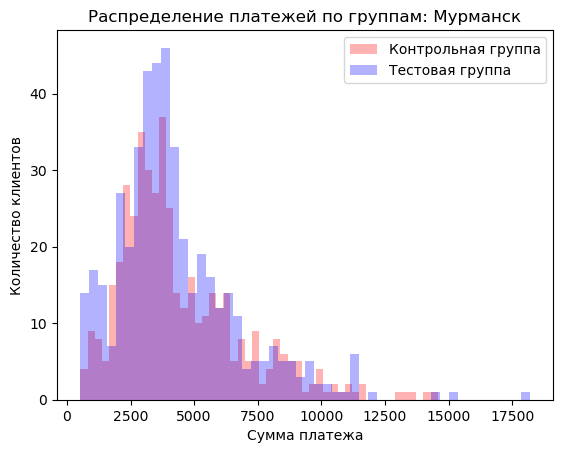

Средний платеж в контрольной группе: 1857.2197183098592
Средний платеж в тестовой группе: 1865.2710900473933
Разница средних платежей: 8.051371737534055
Сравнение средних платежей:
t-критерий: -0.06903013362727022
p-value: 0.9449721500376205
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.4187793427230047
Конверсия в тестовой группе: 0.4369668246445498
Разница конверсий: 0.018187481921545068
Сравнение конверсии:
t-критерий: -0.8459893865240647
p-value: 0.3976542519437607
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 554067.5
p-value: 0.5434251528583327
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Казань


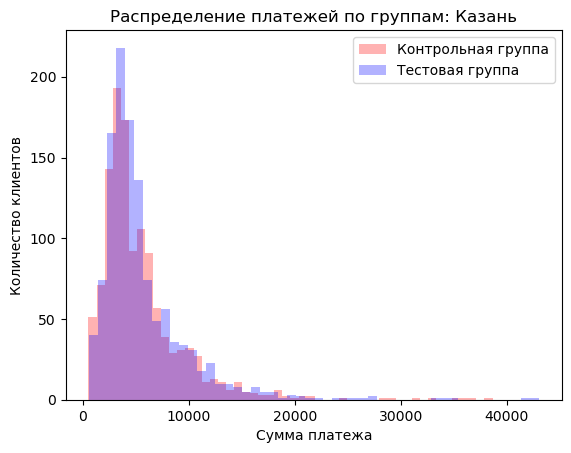

Средний платеж в контрольной группе: 2610.688397361273
Средний платеж в тестовой группе: 2731.9132
Разница средних платежей: 121.22480263872694
Сравнение средних платежей:
t-критерий: -1.0650232928738077
p-value: 0.2869162480777026
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.47497089639115253
Конверсия в тестовой группе: 0.4788
Разница конверсий: 0.003829103608847473
Сравнение конверсии:
t-критерий: -0.2730434342768592
p-value: 0.7848309480845044
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 3178575.0
p-value: 0.37726004167062477
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Саратов


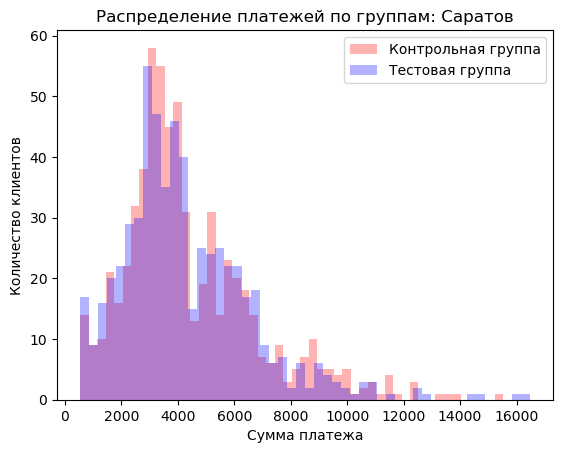

Средний платеж в контрольной группе: 2541.6456266907126
Средний платеж в тестовой группе: 2528.7887462981244
Разница средних платежей: -12.85688039258821
Сравнение средних платежей:
t-критерий: 0.10528758709988616
p-value: 0.916157615818114
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.5743913435527502
Конверсия в тестовой группе: 0.5883514313919053
Разница конверсий: 0.013960087839155033
Сравнение конверсии:
t-критерий: -0.6509212642056408
p-value: 0.5151683778839083
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 557976.5
p-value: 0.7833257779753139
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Тольятти


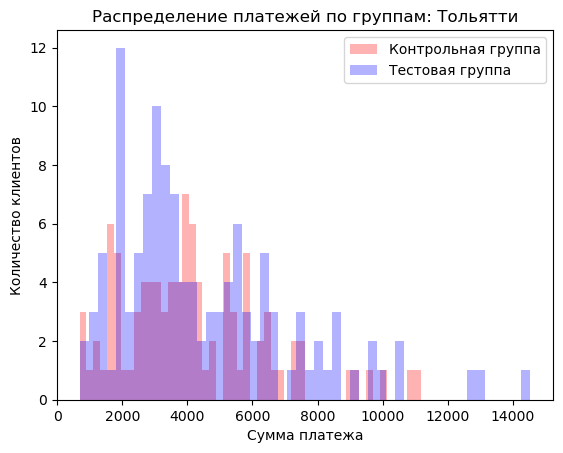

Средний платеж в контрольной группе: 2439.4610778443116
Средний платеж в тестовой группе: 2902.4105263157894
Разница средних платежей: 462.9494484714778
Сравнение средних платежей:
t-критерий: -1.5175500938340993
p-value: 0.13001786285422054
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.5808383233532934
Конверсия в тестовой группе: 0.6421052631578947
Разница конверсий: 0.061266939804601295
Сравнение конверсии:
t-критерий: -1.1829087187887688
p-value: 0.2376568203415723
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 14709.5
p-value: 0.22134177144014489
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Тюмень


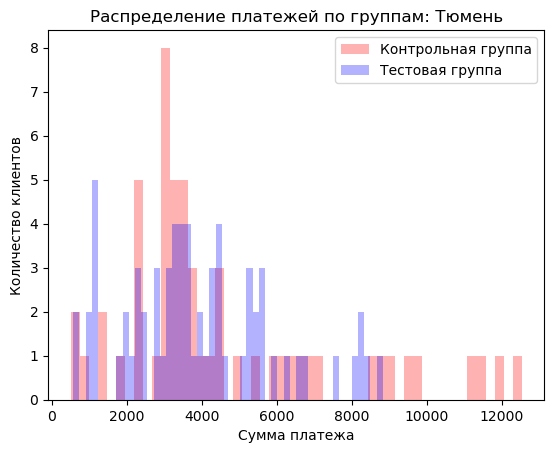

Средний платеж в контрольной группе: 1743.376712328767
Средний платеж в тестовой группе: 2043.823076923077
Разница средних платежей: 300.4463645943099
Сравнение средних платежей:
t-критерий: -0.9355160614445127
p-value: 0.350348399159479
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.3767123287671233
Конверсия в тестовой группе: 0.5230769230769231
Разница конверсий: 0.1463645943097998
Сравнение конверсии:
t-критерий: -2.4554335475106397
p-value: 0.014706455848896271
Существует статистически значимая разница между средними.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 8239.0
p-value: 0.038066216007540725
Существует статистически значимая разница между распределениями выборок.
--------------------------------------------------------------------------------
Город: Волгоград


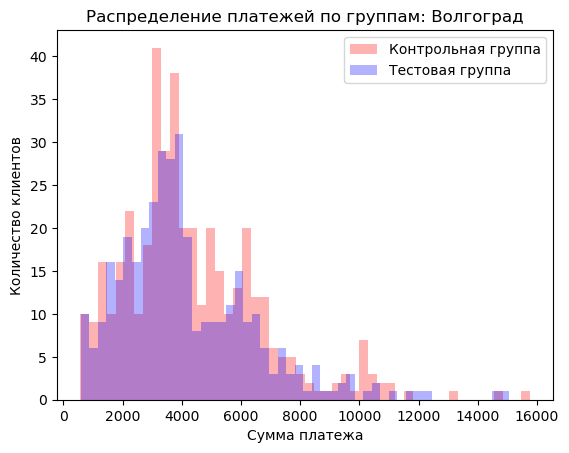

Средний платеж в контрольной группе: 2601.7610241820767
Средний платеж в тестовой группе: 2288.8706240487063
Разница средних платежей: -312.89040013337035
Сравнение средних платежей:
t-критерий: 2.093060153710971
p-value: 0.03652898176795692
Существует статистически значимая разница между средними.
Конверсия в контрольной группе: 0.5960170697012802
Конверсия в тестовой группе: 0.5525114155251142
Разница конверсий: -0.04350565417616603
Сравнение конверсии:
t-критерий: 1.6214876827587115
p-value: 0.10514674877791294
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 245743.0
p-value: 0.03323940159324537
Существует статистически значимая разница между распределениями выборок.
--------------------------------------------------------------------------------
Город: Сочи


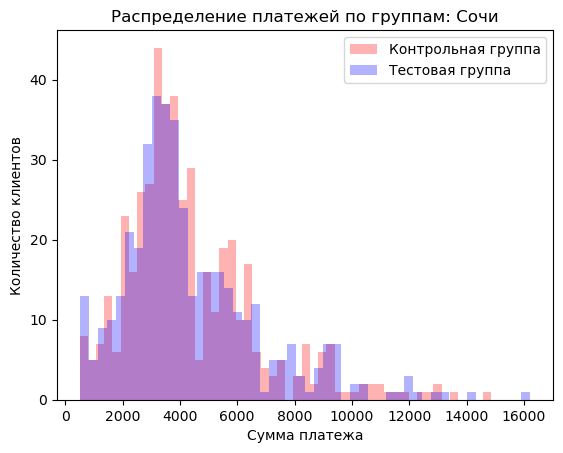

Средний платеж в контрольной группе: 2523.081885856079
Средний платеж в тестовой группе: 2305.8304020100504
Разница средних платежей: -217.2514838460288
Сравнение средних платежей:
t-критерий: 1.5431716085394451
p-value: 0.12298694954093924
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.5744416873449132
Конверсия в тестовой группе: 0.5251256281407035
Разница конверсий: -0.04931605920420967
Сравнение конверсии:
t-критерий: 1.9848326970167756
p-value: 0.04733371440622176
Существует статистически значимая разница между средними.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 337587.5
p-value: 0.05698257474271896
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Владимир


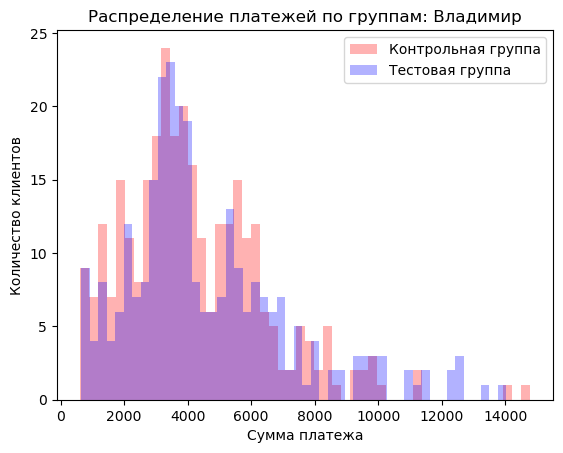

Средний платеж в контрольной группе: 2108.6101973684213
Средний платеж в тестовой группе: 2547.2200392927307
Разница средних платежей: 438.6098419243094
Сравнение средних платежей:
t-критерий: -2.5482347898198
p-value: 0.010972397245538288
Существует статистически значимая разница между средними.
Конверсия в контрольной группе: 0.49835526315789475
Конверсия в тестовой группе: 0.550098231827112
Разница конверсий: 0.05174296866921729
Сравнение конверсии:
t-критерий: -1.7256838092471332
p-value: 0.08468968376236101
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 143847.0
p-value: 0.03166761411886426
Существует статистически значимая разница между распределениями выборок.
--------------------------------------------------------------------------------
Город: Самара


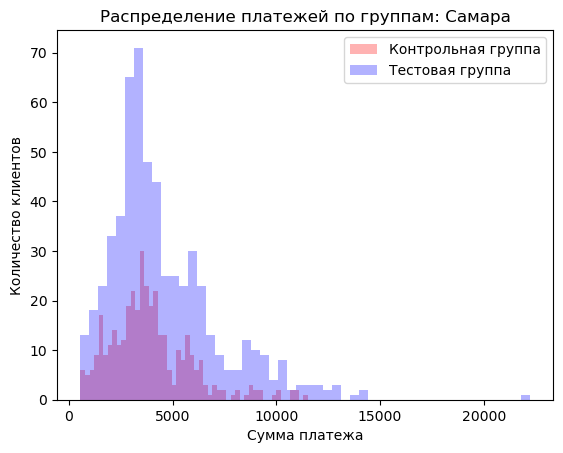

Средний платеж в контрольной группе: 1718.4172576832152
Средний платеж в тестовой группе: 3262.78927680798
Разница средних платежей: 1544.3720191247648
Сравнение средних платежей:
t-критерий: -11.461695457095386
p-value: 3.234375764836726e-29
Существует статистически значимая разница между средними.
Конверсия в контрольной группе: 0.4397163120567376
Конверсия в тестовой группе: 0.7169576059850374
Разница конверсий: 0.2772412939282998
Сравнение конверсии:
t-критерий: -11.876776672348619
p-value: 2.8571540651916067e-31
Существует статистически значимая разница между средними.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 233516.5
p-value: 4.325201867794148e-30
Существует статистически значимая разница между распределениями выборок.
--------------------------------------------------------------------------------
Город: Краснодар


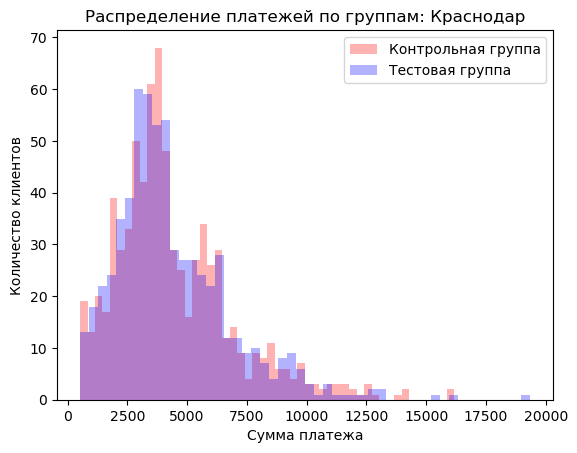

Средний платеж в контрольной группе: 2912.4310798946444
Средний платеж в тестовой группе: 2696.8046875
Разница средних платежей: -215.62639239464443
Сравнение средних платежей:
t-критерий: 1.72050881673007
p-value: 0.08548424195838117
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.6532045654082529
Конверсия в тестовой группе: 0.6142578125
Разница конверсий: -0.03894675290825289
Сравнение конверсии:
t-критерий: 1.8767040535771438
p-value: 0.060695555862541745
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 609837.0
p-value: 0.05938101983441801
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Сахалинск


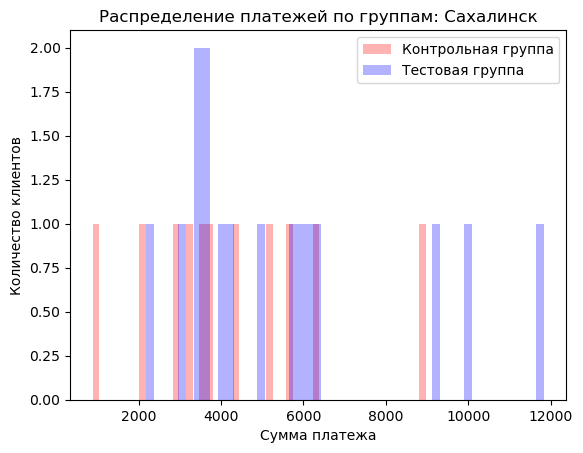

Средний платеж в контрольной группе: 600.1538461538462
Средний платеж в тестовой группе: 1171.4533333333334
Разница средних платежей: 571.2994871794872
Сравнение средних платежей:
t-критерий: -1.614302026019274
p-value: 0.10894456910491815
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.14102564102564102
Конверсия в тестовой группе: 0.21333333333333335
Разница конверсий: 0.07230769230769232
Сравнение конверсии:
t-критерий: -1.166696163228091
p-value: 0.24524633092055417
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 2690.5
p-value: 0.19868569514015844
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------
Город: Дмитров


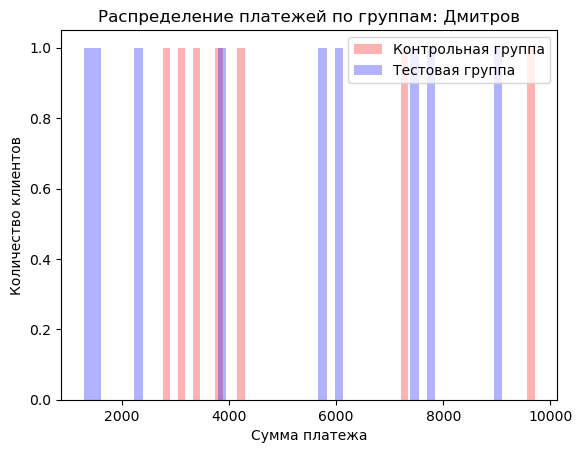

Средний платеж в контрольной группе: 483.4507042253521
Средний платеж в тестовой группе: 579.3333333333334
Разница средних платежей: 95.88262910798124
Сравнение средних платежей:
t-критерий: -0.33288475854446575
p-value: 0.7396957883035645
Статистически значимой разницы между средними нет.
Конверсия в контрольной группе: 0.09859154929577464
Конверсия в тестовой группе: 0.11538461538461539
Разница конверсий: 0.01679306608884075
Сравнение конверсии:
t-критерий: -0.3296443841453943
p-value: 0.7421382534980077
Статистически значимой разницы между средними нет.
Критерий Манна — Уитни для платежей:
U-статистика Манна-Уитни: 2722.0
p-value: 0.7422551789442879
Нет статистически значимой разницы между распределениями выборок.
--------------------------------------------------------------------------------


In [68]:
df_other_city = df_filtered[~df_filtered['city'].isin(['Москва', 'Санкт-Петербург'])].copy()     # создаём таблицу по всем городам, кроме Москвы и Санкт-Петербурга

for city in df_other_city['city'].unique():                                              # запускаем цикл по всем оставшимся городам
    
    print('Город:', city)                                                                # выводим название города
    
    df_city = df_other_city[df_other_city['city'] == city].copy()                        # отбираем данные только по текущему городу
    r1_payment_city = df_city[df_city['nflag_test'] == 0]['amt_payment']                 # формируем выборку платежей контрольной группы
    r2_payment_city = df_city[df_city['nflag_test'] == 1]['amt_payment']                 # формируем выборку платежей тестовой группы
    r1_conversion_city = df_city[df_city['nflag_test'] == 0]['payment_flag']             # формируем выборку флагов платежа контрольной группы
    r2_conversion_city = df_city[df_city['nflag_test'] == 1]['payment_flag']             # формируем выборку флагов платежа тестовой группы
    df_city_for_hist = df_city[df_city['amt_payment'] > 0]                               # создаём отдельную таблицу только для графика, исключая нулевые платежи
    
    plt.hist(                                                                            # строим гистограмму платежей для контрольной группы
        df_city_for_hist[df_city_for_hist['nflag_test'] == 0]['amt_payment'],
        color='red',
        alpha=0.3,
        label='Контрольная группа',
        bins=50
    )
    
    plt.hist(                                                                             # строим гистограмму платежей для тестовой группы
        df_city_for_hist[df_city_for_hist['nflag_test'] == 1]['amt_payment'],
        color='blue',
        alpha=0.3,
        label='Тестовая группа',
        bins=50
    )
    
    plt.xlabel('Сумма платежа')                                                           # офрмление графика
    plt.ylabel('Количество клиентов')
    plt.title('Распределение платежей по группам: ' + city)
    plt.legend(loc='upper right')
    
    plt.show()                                                                            # отображаем график
    
    control_avg_payment_city = r1_payment_city.mean()                                     # считаем средний платеж в контрольной группе
    test_avg_payment_city = r2_payment_city.mean()                                        # считаем средний платеж в тестовой группе
    control_conversion_city = r1_conversion_city.mean()                                   # считаем конверсию в контрольной группе                  
    test_conversion_city = r2_conversion_city.mean()                                      # считаем конверсию в тестовой группе
    
    print('Средний платеж в контрольной группе:', control_avg_payment_city)               # выводим средние платежи
    print('Средний платеж в тестовой группе:', test_avg_payment_city)
    print('Разница средних платежей:', test_avg_payment_city - control_avg_payment_city)
    
    print('Сравнение средних платежей:')                                                  # сравниваем средние платежи
    test_calc(r1_payment_city, r2_payment_city)
    
    print('Конверсия в контрольной группе:', control_conversion_city)                     # выводим конверсии
    print('Конверсия в тестовой группе:', test_conversion_city)
    print('Разница конверсий:', test_conversion_city - control_conversion_city)
    
    print('Сравнение конверсии:')                                                         # сравниваем конверсию
    test_calc(r1_conversion_city, r2_conversion_city)
    
    print('Критерий Манна — Уитни для платежей:')                                         # сравниваем распределения платежей
    mann_whitney_func(r1_payment_city, r2_payment_city)
    
    print('-' * 80)                                                                       # добавляем разделитель между городами

По остальным городам результаты A/B-теста оказались неоднородными. В большинстве городов статистически значимой разницы между тестовой и контрольной группами не обнаружено: p-value по среднему платежу, конверсии или критерию Манна — Уитни больше 0.05.
Значимое положительное влияние тестовой механики заметно в отдельных городах. В Самаре тестовая группа показала улучшение и по среднему платежу, и по конверсии, а различия статистически значимы. Также положительный эффект по среднему платежу наблюдается во Владимире и Краснодаре. В Тюмени статистически значимое улучшение выявлено по конверсии.
При этом в Волгограде тестовая группа показала результат хуже контрольной по среднему платежу, и различие оказалось статистически значимым. Это говорит о том, что эффект новой механики зависит от города.
Таким образом, по другим городам нельзя сделать однозначный вывод о повсеместном преимуществе пуш-уведомлений. Тестовая механика показывает хорошие результаты в части городов, но эффект неодинаковый, поэтому при внедрении стоит учитывать региональную специфику.

## Отчет по A/B-тесту

In [69]:
result = []                                                                       # создаём пустой список

total_count = len(df_filtered)                                                    # считаем общее количество наблюдений в очищенной таблице
for city in df_filtered['city'].unique():                                         # запускаем цикл по всем городам
    df_city = df_filtered[df_filtered['city'] == city]                            # отбираем данные только по текущему городу
    for trading_point in df_city['id_trading_point'].unique():                    # запускаем цикл по всем торговым точкам текущего города
        df_point = df_city[df_city['id_trading_point'] == trading_point]          # отбираем данные только по текущей торговой точке
        payments_test = df_point[df_point['nflag_test'] == 1]['amt_payment']      # формируем выборку платежей тестовой группы
        payments_control = df_point[df_point['nflag_test'] == 0]['amt_payment']   # формируем выборку платежей контрольной группы
        count_test = len(payments_test)                                           # считаем количество наблюдений в тестовой группе
        count_control = len(payments_control)                                     # считаем количество наблюдений в контрольной группе
        count_all = count_test + count_control                                    # считаем общее количество наблюдений по торговой точке
        percent_count = count_all / total_count                                   # считаем долю наблюдений данной торговой точки от всех наблюдений
        avg_payment_test = payments_test.mean()                                   # считаем средний платеж в тестовой группе
        avg_payment_control = payments_control.mean()                             # считаем средний платеж в контрольной группе
        diff = avg_payment_test - avg_payment_control                             # считаем разницу между средними платежами
        sigma_test = payments_test.std()                                          # считаем стандартное отклонение платежей в тестовой группе
        sigma_control = payments_control.std()                                    # считаем стандартное отклонение платежей в контрольной группе
        ttest, pvalue_ttest = stats.ttest_ind(                                    # рассчитываем t-критерий и p-value для сравнения средних платежей
            payments_test,
            payments_control,
            equal_var=False
        )
        
        if np.isnan(pvalue_ttest):                                                # задаём лейбл результата по торговой точке
            label = 'neutral'
        elif diff > 0 and pvalue_ttest < 0.05:
            label = 'positive'
        elif diff < 0 and pvalue_ttest < 0.05:
            label = 'negative'
        else:
            label = 'neutral'
        
        row = {                                                                   # создаём строку с результатами по текущей торговой точке
            'city': city,
            'id_trading_point': trading_point,
            'count_test': count_test,
            'count_control': count_control,
            'count_all': count_all,
            'percent_count': percent_count,
            'avg_payment_test': avg_payment_test,
            'avg_payment_control': avg_payment_control,
            'diff': diff,
            'sigma_test': sigma_test,
            'sigma_control': sigma_control,
            'ttest': ttest,
            'pvalue_ttest': pvalue_ttest,
            'label': label
        }
        
        result.append(row)                                                        # добавляем строку в список результатов

df_result = pd.DataFrame(result)                                                  # преобразуем список результатов в датафрейм
df_result                                                                         # выводим итоговую таблицу

,city,id_trading_point,count_test,count_control,count_all,percent_count,avg_payment_test,avg_payment_control,diff,sigma_test,sigma_control,ttest,pvalue_ttest,label
0,Красноярск,212,593,575,1168,0.025773,2144.317032,2222.052174,-77.735142,2708.588724,2785.116250,-0.483378,6.289187e-01,neutral
1,Красноярск,278,535,489,1024,0.022596,2499.345794,2185.214724,314.131070,2915.995329,2574.915597,1.830426,6.747772e-02,neutral
2,Красноярск,202,551,565,1116,0.024626,2927.341198,2730.378761,196.962437,2956.686241,2737.885785,1.153961,2.487664e-01,neutral
3,Красноярск,444,650,562,1212,0.026744,2404.106154,2545.734875,-141.628722,2810.828487,2797.138764,-0.877051,3.806362e-01,neutral
4,Красноярск,277,708,709,1417,0.031268,2285.750000,2431.365303,-145.615303,2712.677878,2868.587569,-0.981744,3.263942e-01,neutral
5,Мурманск,54,633,640,1273,0.028090,1702.714060,1688.512500,14.201560,2565.132440,2628.012490,0.097569,9.222902e-01,neutral
6,Мурманск,55,422,425,847,0.018690,2109.106635,2111.272941,-2.166306,2790.993385,2804.223188,-0.011268,9.910123e-01,neutral
7,Казань,991,270,294,564,0.012445,3249.281481,2452.986395,796.295087,4719.592601,3633.935858,2.230816,2.613223e-02,positive
8,Казань,699,482,494,976,0.021537,2422.286307,2574.352227,-152.065920,3906.817897,4082.851356,-0.594576,5.522650e-01,neutral
9,Казань,477,382,386,768,0.016947,2259.623037,2496.987047,-237.364010,3482.846094,3881.994719,-0.892096,3.726243e-01,neutral


In [70]:
df_positive = df_result[df_result['label'] == 'positive']                           # торговые точки с положительным результатом
df_negative = df_result[df_result['label'] == 'negative']                           # торговые точки с отрицательным результатом
df_neutral = df_result[df_result['label'] == 'neutral']                             # торговые точки с нейтральным результатом

In [71]:
file_name = 'Калькулятор АВ теста.xlsx'                                                # задаём название Excel-файла

with pd.ExcelWriter(file_name, engine='openpyxl') as writer:                        # выгружаем результаты в Excel на три разных листа
    df_positive.to_excel(writer, sheet_name='positive', index=False)                # выгружаем положительные результаты
    df_negative.to_excel(writer, sheet_name='negative', index=False)                # выгружаем отрицательные результаты
    df_neutral.to_excel(writer, sheet_name='neutral', index=False)                  # выгружаем нейтральные результаты

print('Файл успешно выгружен:', file_name)                                          # выводим сообщение об успешной выгрузке

Файл успешно выгружен: Калькулятор АВ теста.xlsx
